In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('../.customized_mplstyle')
import straxion
straxion.register_xenon_colors()

In [9]:
coverage_df = pd.read_csv("../production2/coverage/coverage_results.csv")
sensitivity_df = pd.read_csv("../production2/sensitivity/sensitivity_band.csv")

In [22]:
sensitivity_df

,m_test,lower_2sigma,lower_1sigma,median,upper_1sigma,upper_2sigma,limit
0,0.0130,1.385015e-11,1.801067e-11,2.591618e-11,3.412820e-11,4.285276e-11,1.371535e-11
1,0.0158,1.082252e-11,1.512199e-11,2.108468e-11,2.757871e-11,3.382527e-11,1.054264e-11
2,0.0191,9.637823e-12,1.178386e-11,1.601486e-11,2.166914e-11,2.589933e-11,9.528047e-12
3,0.0231,6.806271e-12,9.020953e-12,1.217606e-11,1.571612e-11,1.872361e-11,6.846194e-12
4,0.0280,4.252436e-12,5.380932e-12,7.458408e-12,9.476072e-12,1.151741e-11,4.127838e-12
5,0.0340,1.848347e-12,2.762876e-12,4.308630e-12,5.996651e-12,7.403467e-12,2.234195e-12
6,0.0412,4.830630e-13,1.425980e-12,2.597884e-12,3.693394e-12,4.510831e-12,1.800409e-12
7,0.0499,1.554666e-13,1.037638e-12,1.815394e-12,2.408961e-12,2.928379e-12,1.552094e-12
8,0.0604,5.734711e-13,1.335626e-12,2.311696e-12,3.155198e-12,3.771810e-12,2.406288e-12
9,0.0732,2.034953e-12,2.883590e-12,4.594069e-12,5.852940e-12,7.005167e-12,5.591932e-12


In [12]:
np.unique(coverage_df.mass_eV)

array([0.013 , 0.0231, 0.0499, 0.0732, 0.13  , 0.341 ])

In [13]:
coverage_df

,mass_eV,chi_true,n_toy,analysis_coverage,analysis_unc,interval_coverage,interval_unc
0,0.013,0.000000e+00,1001,0.489510,0.015800,1.000000,0.000000
1,0.013,5.000000e-12,1001,1.000000,0.000000,0.894106,0.009726
2,0.013,1.000000e-11,1001,1.000000,0.000000,0.891109,0.009846
3,0.013,2.000000e-11,1001,0.954046,0.006618,0.881119,0.010230
4,0.013,3.000000e-11,1001,0.936064,0.007732,0.870130,0.010625
...,...,...,...,...,...,...,...
67,0.341,6.000000e-11,1001,1.000000,0.000000,0.899101,0.009520
68,0.341,7.000000e-11,1001,0.999001,0.000999,0.912088,0.008950
69,0.341,8.000000e-11,1001,0.999001,0.000999,0.930070,0.008061
70,0.341,9.000000e-11,1001,0.999001,0.000999,0.957043,0.006409


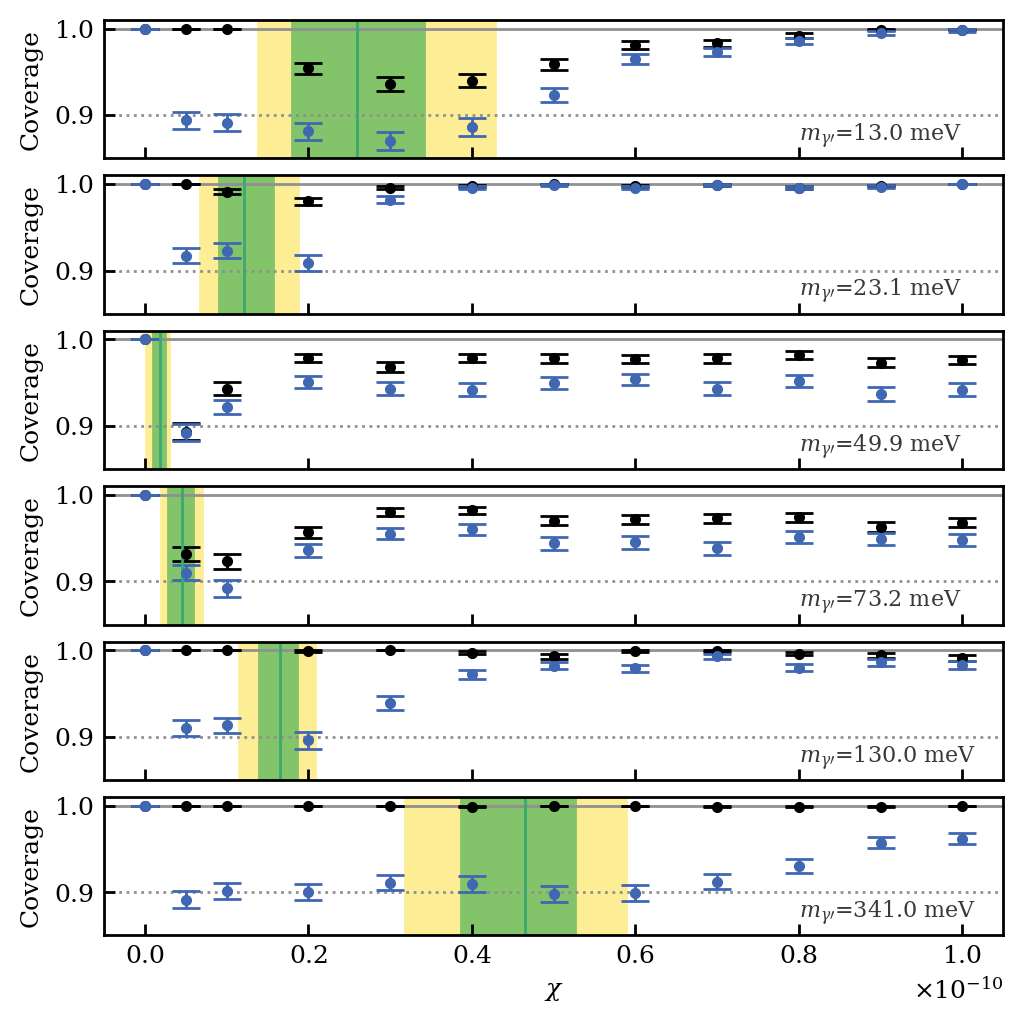

In [41]:
coverage_arr = coverage_df.to_records(index=False)
masses = np.unique(coverage_df.mass_eV)

fig, axes = plt.subplots(
    len(masses),
    1,
    sharex=True,
    figsize=(5, 5),
    constrained_layout=True,
)

if len(masses) == 1:
    axes = [axes]

for i, m in enumerate(masses):
    selected = coverage_arr[coverage_arr["mass_eV"] == m].copy()
    selected["analysis_coverage"][0] = 1
    selected["analysis_unc"][0] = 0

    sens_row = sensitivity_df[
        np.isclose(sensitivity_df["m_test"], m, rtol=0, atol=1e-12)
    ]
    if sens_row.empty:
        raise ValueError(f"No sensitivity row found for mass {m}")
    sens_row = sens_row.iloc[0]

    ax = axes[i]
    ax.errorbar(
        selected["chi_true"],
        selected["analysis_coverage"],
        selected["analysis_unc"],
        label="Analysis Coverage",
        fmt="o",
        capsize=5,
    )
    ax.errorbar(
        selected["chi_true"],
        selected["interval_coverage"],
        selected["interval_unc"],
        label="Feldman-Cousins Coverage",
        fmt="o",
        capsize=5,
    )

    ax.axvspan(
        sens_row["lower_2sigma"],
        sens_row["upper_2sigma"],
        color="xenon_2sigma_yellow",
        label="Sensitivity central 2$\\sigma$",
        zorder=-2,
    )
    ax.axvspan(
        sens_row["lower_1sigma"],
        sens_row["upper_1sigma"],
        color="xenon_1sigma_green",
        label="Sensitivity central 1$\\sigma$",
        zorder=-2,
    )
    ax.axvline(
        sens_row["median"],
        color="xenon_green",
        label="Median sensitivity",
        zorder=2,
    )
    ax.axhline(0.9, color="xenon_grey", linestyle=":", zorder=-1)
    ax.axhline(1, color="xenon_grey", zorder=-1)
    ax.set_ylim(0.85, 1.01)
    ax.set_ylabel("Coverage")
    ax.text(0.8e-10, 0.87, fr"$m_{{\gamma\prime}}$={m * 1e3:.1f} meV", fontsize=8, color="xenon_jet")
    #ax.set_title(f"m = {m * 1e3:.1f} meV")

axes[-1].set_xlabel(r"$\chi$")
#axes[0].legend(loc="best")
plt.savefig("plots/coverage.pdf")
plt.show()